In [8]:
# SHAP Explainability Pipeline Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

print("Step 1: Re-initializing preprocessed datasets and pipeline arrays...")
fraud_data = pd.read_csv('../data/raw/Fraud_Data.csv').drop_duplicates()
ip_data = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Parse timestamps
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

# Vectorized IP lookup array mapping
fraud_data['ip_int'] = fraud_data['ip_address'].fillna(0).astype(np.int64)
ip_sorted = ip_data.sort_values(by='lower_bound_ip_address').reset_index(drop=True)
idx = np.searchsorted(ip_sorted['lower_bound_ip_address'].values, fraud_data['ip_int'].values) - 1
idx = np.clip(idx, 0, len(ip_sorted) - 1)
valid_mask = (fraud_data['ip_int'].values >= ip_sorted['lower_bound_ip_address'].values[idx]) & \
             (fraud_data['ip_int'].values <= ip_sorted['upper_bound_ip_address'].values[idx])
fraud_data['country'] = np.where(valid_mask, ip_sorted['country'].values[idx], 'Unknown')

# Feature Extraction
fraud_data['time_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds()
fraud_data['hour_of_day'] = fraud_data['purchase_time'].dt.hour
fraud_data['day_of_week'] = fraud_data['purchase_time'].dt.dayofweek
fraud_data['user_device_count'] = fraud_data.groupby('device_id')['user_id'].transform('count')
fraud_data['user_ip_count'] = fraud_data.groupby('ip_address')['user_id'].transform('count')

# Handle Categoricals and drop tracking strings
categorical_cols = ['source', 'browser', 'sex', 'country']
encoded_df = pd.get_dummies(fraud_data, columns=categorical_cols, drop_first=True)
drop_identifiers = ['user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address', 'ip_int', 'class']

X = encoded_df.drop(columns=drop_identifiers)
y = encoded_df['class']

# Re-establish Train-Test Splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
numerical_features = ['purchase_value', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_device_count', 'user_ip_count']
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# Train Winning Model Candidate
print("Training structural Random Forest model with SMOTE input rows...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

print("Pipeline initialization complete!")

C:\Users\Rio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step 1: Re-initializing preprocessed datasets and pipeline arrays...
Training structural Random Forest model with SMOTE input rows...
Pipeline initialization complete!


Step 2: Extracting native Tree Feature Importance scores...


C:\Users\Rio\AppData\Local\Temp\ipykernel_24240\265403113.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:10]], y=X_train.columns[indices[:10]], palette="viridis")


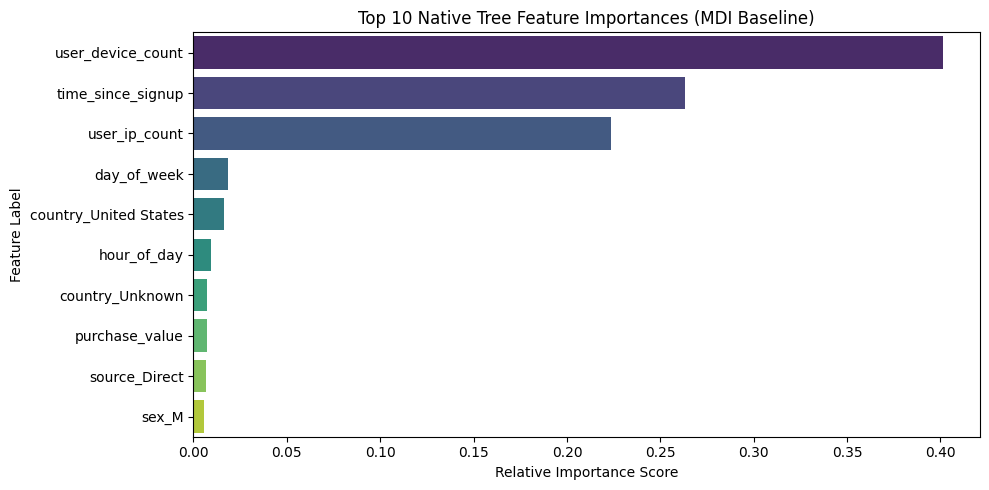

In [2]:
print("Step 2: Extracting native Tree Feature Importance scores...")
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices[:10]], y=X_train.columns[indices[:10]], palette="viridis")
plt.title("Top 10 Native Tree Feature Importances (MDI Baseline)")
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature Label")
plt.tight_layout()
plt.show()

Step 3: Building TreeExplainer and mapping global SHAP values...
Rendering Global SHAP Summary Scatter Graph...


<Figure size 1000x600 with 0 Axes>

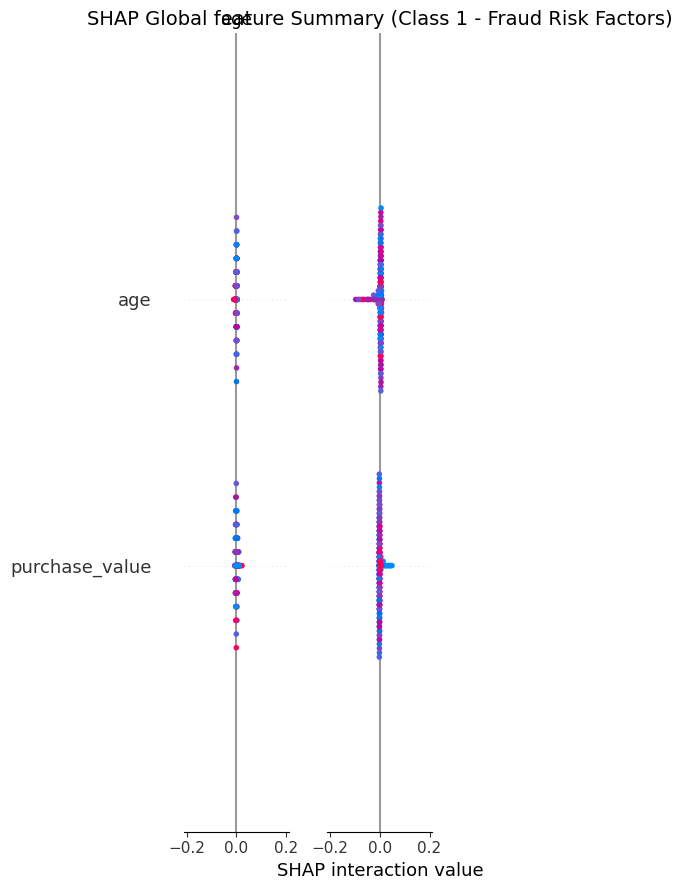

In [4]:
print("Step 3: Building TreeExplainer and mapping global SHAP values...")
explainer = shap.TreeExplainer(rf_model)

# Extract an optimized, balanced sampling slice to evaluate safely
X_shap_sample = X_test.sample(200, random_state=42)
shap_values = explainer.shap_values(X_shap_sample)

# Align format arrays depending on package version states
shap_obj = shap_values[1] if isinstance(shap_values, list) else shap_values

print("Rendering Global SHAP Summary Scatter Graph...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_obj, X_shap_sample, max_display=10, show=False)
plt.title("SHAP Global feature Summary (Class 1 - Fraud Risk Factors)", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
print("Step 4: Identifying target case studies across prediction categories...")
test_predictions = rf_model.predict(X_test)

# Pull matching matrix coordinates
true_positives = np.where((test_predictions == 1) & (y_test.values == 1))[0]
false_positives = np.where((test_predictions == 1) & (y_test.values == 0))[0]
false_negatives = np.where((test_predictions == 0) & (y_test.values == 1))[0]

cases_to_plot = {
    "True Positive (Correctly Flagged Fraud)": true_positives[0],
    "False Positive (Legitimate Flagged as Fraud)": false_positives[0],
    "False Negative (Missed Fraud Instance)": false_negatives[0]
}

print(f"Isolated Case Targets -> TP Index: {true_positives[0]} | FP Index: {false_positives[0]} | FN Index: {false_negatives[0]}")

Step 4: Identifying target case studies across prediction categories...
Isolated Case Targets -> TP Index: 2 | FP Index: 16 | FN Index: 17


In [7]:
print("Step 5: Extracting localized contribution weights...")
base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

for name, idx_pos in cases_to_plot.items():
    row_data = X_test.iloc[[idx_pos]]
    
    # Force evaluation extraction to isolate Class 1 specifically
    raw_row_shap = explainer.shap_values(row_data)
    if isinstance(raw_row_shap, list):
        row_shap = raw_row_shap[1][0]
    elif len(raw_row_shap.shape) == 3:
        row_shap = raw_row_shap[0, :, 1]
    else:
        row_shap = raw_row_shap[0]
        
    print(f"\n==================================================================")
    print(f"LOCAL BREAKDOWN: {name} (Row Index {idx_pos})")
    print(f"System Base Probability Level: {base_val:.4f}")
    
    # Bundle feature metrics with flattened single-value elements
    contributions = list(zip(X_test.columns, row_data.values[0], row_shap))
    sorted_drivers = sorted(contributions, key=lambda x: abs(float(x[2])), reverse=True)
    
    print("Primary Predictive Drivers:")
    for feat, raw_val, sh_v in sorted_drivers[:3]:
        impact_direction = "PUSHING TOWARD FRAUD (+)" if sh_v > 0 else "PULLING TOWARD SAFE (-)"
        print(f" * {feat:<22} | Normalized Feature Value: {raw_val:>6.2f} | SHAP Impact: {sh_v:>7.4f} ({impact_direction})")

Step 5: Extracting localized contribution weights...

LOCAL BREAKDOWN: True Positive (Correctly Flagged Fraud) (Row Index 2)
System Base Probability Level: 0.5000
Primary Predictive Drivers:
 * user_device_count      | Normalized Feature Value:   0.12 | SHAP Impact:  0.2071 (PUSHING TOWARD FRAUD (+))
 * time_since_signup      | Normalized Feature Value:   0.07 | SHAP Impact: -0.0763 (PULLING TOWARD SAFE (-))
 * user_ip_count          | Normalized Feature Value:  -0.23 | SHAP Impact: -0.0441 (PULLING TOWARD SAFE (-))

LOCAL BREAKDOWN: False Positive (Legitimate Flagged as Fraud) (Row Index 16)
System Base Probability Level: 0.5000
Primary Predictive Drivers:
 * user_device_count      | Normalized Feature Value:   0.12 | SHAP Impact:  0.1973 (PUSHING TOWARD FRAUD (+))
 * time_since_signup      | Normalized Feature Value:   1.15 | SHAP Impact: -0.0721 (PULLING TOWARD SAFE (-))
 * user_ip_count          | Normalized Feature Value:  -0.23 | SHAP Impact: -0.0355 (PULLING TOWARD SAFE (-))

LO